# Модуль 5: Оценка и Анализ Ошибок
Расчет Perplexity, BLEU, ROUGE. Сравнение LSTM vs ruGPT-3.

In [1]:
import os
os.environ['USE_TF'] = '0'
os.environ['TRANSFORMERS_NO_TF'] = '1'

import torch
import pandas as pd
import numpy as np
import math
import evaluate
import random

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)
print('Packages loaded!')

Device: cuda
Packages loaded!


In [2]:
bleu_metric  = evaluate.load('bleu')
rouge_metric = evaluate.load('rouge')
print('BLEU and ROUGE are ready')

BLEU and ROUGE are ready


## 1. Загрузка моделей

In [3]:
# --- ruGPT-3 ---
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

device_id = 0 if device == 'cuda' else -1
gpt_path = './abai_rugpt3_final'

if os.path.exists(gpt_path):
    gpt_tokenizer = AutoTokenizer.from_pretrained(gpt_path)
    gpt_model = AutoModelForCausalLM.from_pretrained(gpt_path).to(device)
    generator = pipeline('text-generation', model=gpt_model, tokenizer=gpt_tokenizer, device=device_id)
    print('ruGPT-3 loaded on device:', device)
else:
    raise FileNotFoundError('Directory ./abai_rugpt3_final not found! Run Module 4.')

ruGPT-3 loaded on device: cuda


In [4]:
# --- LSTM ---
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

lstm_model = tf.keras.models.load_model('lstm_baseline.keras')

with open('data/tokenizer.pkl', 'rb') as f:
    lstm_tokenizer = pickle.load(f)

import numpy as np
X = np.load('data/lstm_X.npy')
max_sequence_len = X.shape[1] + 1

print('LSTM loaded. max_sequence_len:', max_sequence_len)

LSTM loaded. max_sequence_len: 90


## 2. Подготовка данных для честного сравнения
Берём реальные предложения Абая. Разрезаем пополам:
- **Первая половина** → затравка для модели
- **Вторая половина** → эталон (reference) для BLEU/ROUGE

In [5]:
df = pd.read_csv('data/train_sentences.csv')
sentences = df['sentence'].dropna().tolist()

# Фильтруем только достаточно длинные предложения (минимум 8 слов)
long_sents = [s for s in sentences if len(s.split()) >= 8]
random.seed(42)
sample = random.sample(long_sents, min(10, len(long_sents)))

seeds = []
references = []
for sent in sample:
    words = sent.split()
    mid = len(words) // 2
    seed = ' '.join(words[:mid])        # первая половина = затравка
    ref  = ' '.join(words[mid:])        # вторая половина = эталон
    seeds.append(seed)
    references.append(ref)

print(f'Prepared {len(seeds)} pairs (seed → reference)')
print(f'\nExample:')
print(f'  Seed:      {seeds[0]}')
print(f'  Reference: {references[0]}')

Prepared 10 pairs (seed → reference)

Example:
  Seed:      - алланың ғылымы емес, һәмманы білетұғын ғылымға
  Reference: ынтықтық, өзі де адамға өзіндік ғылым береді.


## 3. Генерация текста обеими моделями

In [6]:
# Функция генерации GPT
def gen_gpt(seed, max_tokens=30):
    out = generator(seed, max_new_tokens=max_tokens, do_sample=False,
                    num_beams=3,
                    num_return_sequences=1,
                    pad_token_id=gpt_tokenizer.eos_token_id)
    full = out[0]['generated_text']
    # Возвращаем только новую часть (без затравки)
    return full[len(seed):].strip()

# Функция генерации LSTM
def gen_lstm(seed_text, n_words=15):
    result_words = []
    for _ in range(n_words):
        token_list = lstm_tokenizer.texts_to_sequences([seed_text + ' ' + ' '.join(result_words)])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
        predicted_probs = lstm_model.predict(token_list, verbose=0)[0]
        predicted_id = np.argmax(predicted_probs)
        output_word = ''
        for word, index in lstm_tokenizer.word_index.items():
            if index == predicted_id:
                output_word = word
                break
        if output_word:
            result_words.append(output_word)
    return ' '.join(result_words)

print('Generating texts...')
preds_gpt  = [gen_gpt(s)  for s in seeds]
preds_lstm = [gen_lstm(s) for s in seeds]

print('\n=== Example Outputs ===')
for i in range(3):
    print(f'\nSeed:      {seeds[i]}')
    print(f'Reference: {references[i]}')
    print(f'GPT:       {preds_gpt[i]}')
    print(f'LSTM:      {preds_lstm[i]}')

Generating texts...



=== Example Outputs ===

Seed:      - алланың ғылымы емес, һәмманы білетұғын ғылымға
Reference: ынтықтық, өзі де адамға өзіндік ғылым береді.
GPT:       һәмманы білетұғын ғылымы емес, һәм
LSTM:      иман бір бірдей да түрлі ой да пе бір бір бір бір бір бір бір

Seed:      Біз ортамызда оның мархамат, ғадаләтті иманның шартынан хисап қылмаймыз, бұл үшін
Reference: муслим болғанда, алла тағалаға тәслим болып, оның жолында болмақ едік, болғанымыз қайсы?
GPT:       мүмкін болған соң, ғадаләтті иманның шарты
LSTM:      бір бір бір бір бір бір бір бір бір бір бір бір бір бір бір

Seed:      Енді қартайғанда қызығын өзің түгел көре алмайтұғын, ұры, залым, тілемсектердің
Reference: азығын бағып беремін деп, қалған аз ғана өмірімді қор жайым жоқ.
GPT:       де көре алмайтұғын, өзің де залым, өзі
LSTM:      деп жылы деп жылы деп жылы деп жылы деп жылы жоқ ма екен екен екен


## 4. Perplexity

In [7]:
df_test = pd.read_csv('data/test.csv')
test_texts = df_test['text'].dropna().apply(lambda x: str(x)[:200]).tolist()

gpt_model.eval()
losses = []
with torch.no_grad():
    for t in test_texts:
        inp = gpt_tokenizer(t, return_tensors='pt', truncation=True, max_length=128).to(device)
        out = gpt_model(**inp, labels=inp['input_ids'])
        losses.append(out.loss.item())

ppl = math.exp(np.mean(losses))
print(f'Perplexity (ruGPT-3): {ppl:.2f}  (lower is better)')

Perplexity (ruGPT-3): 23.68  (lower is better)


## 5. BLEU and ROUGE

In [8]:
# BLEU ожидает [[ref1], [ref2], ...]
refs_for_bleu = [[r] for r in references]

bleu_gpt  = bleu_metric.compute(predictions=preds_gpt,  references=refs_for_bleu, max_order=2)
bleu_lstm = bleu_metric.compute(predictions=preds_lstm, references=refs_for_bleu, max_order=2)

rouge_gpt  = rouge_metric.compute(predictions=preds_gpt,  references=references, tokenizer=lambda x: str(x).split())
rouge_lstm = rouge_metric.compute(predictions=preds_lstm, references=references, tokenizer=lambda x: str(x).split())

print('=' * 55)
print('  EVALUATION RESULTS')
print('=' * 55)
print(f'{"Metric":<14} {"ruGPT-3":>12} {"LSTM":>12}')
print('-' * 55)
print(f'{"Perplexity ↓":<14} {ppl:>12.2f} {"N/A":>12}')
print(f'{"BLEU ↑":<14} {bleu_gpt["bleu"] * 100:>12.4f} {bleu_lstm["bleu"] * 100:>12.4f}')
print(f'{"ROUGE-1 ↑":<14} {rouge_gpt["rouge1"] * 100:>12.4f} {rouge_lstm["rouge1"] * 100:>12.4f}')
print(f'{"ROUGE-2 ↑":<14} {rouge_gpt["rouge2"] * 100:>12.4f} {rouge_lstm["rouge2"] * 100:>12.4f}')
print(f'{"ROUGE-L ↑":<14} {rouge_gpt["rougeL"] * 100:>12.4f} {rouge_lstm["rougeL"] * 100:>12.4f}')
print('=' * 55)

  EVALUATION RESULTS
Metric              ruGPT-3         LSTM
-------------------------------------------------------
Perplexity ↓          23.68          N/A
BLEU ↑               2.7890       0.0000
ROUGE-1 ↑            2.1765       0.0000
ROUGE-2 ↑            0.0000       0.0000
ROUGE-L ↑            2.1765       0.0000


Сводная таблица:
 Модель  BLEU (%)  ROUGE-1 (%)  ROUGE-2 (%)  ROUGE-L (%)  Perplexity
ruGPT-3  2.788983     2.176471          0.0     2.176471   23.682521
   LSTM  0.000000     0.000000          0.0     0.000000         NaN


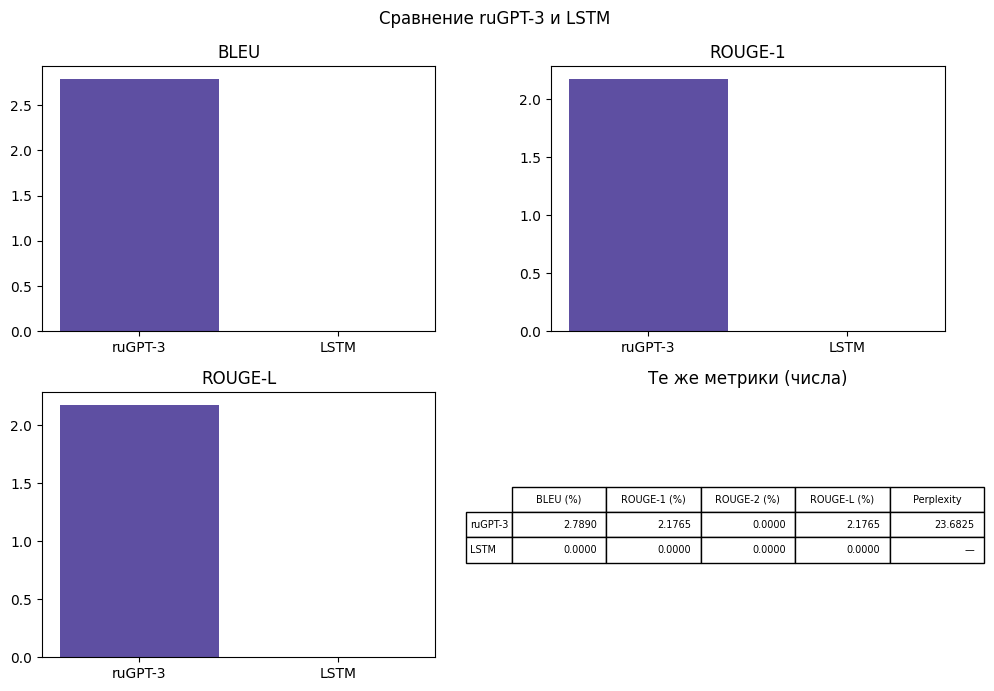

In [9]:
# Табличная + графическая интерпретация метрик (ТЗ 3.3)
import matplotlib.pyplot as plt

def _pct(x):
    return float(x) * 100

metrics_tbl = pd.DataFrame({
    'Модель': ['ruGPT-3', 'LSTM'],
    'BLEU (%)': [_pct(bleu_gpt['bleu']), _pct(bleu_lstm['bleu'])],
    'ROUGE-1 (%)': [_pct(rouge_gpt['rouge1']), _pct(rouge_lstm['rouge1'])],
    'ROUGE-2 (%)': [_pct(rouge_gpt['rouge2']), _pct(rouge_lstm['rouge2'])],
    'ROUGE-L (%)': [_pct(rouge_gpt['rougeL']), _pct(rouge_lstm['rougeL'])],
})
metrics_tbl['Perplexity'] = [ppl, np.nan]

print('Сводная таблица:')
print(metrics_tbl.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
colors = ['#5e4fa2', '#7abf4c']
axes[0, 0].bar(metrics_tbl['Модель'], metrics_tbl['BLEU (%)'], color=colors)
axes[0, 0].set_title('BLEU')
axes[0, 1].bar(metrics_tbl['Модель'], metrics_tbl['ROUGE-1 (%)'], color=colors)
axes[0, 1].set_title('ROUGE-1')
axes[1, 0].bar(metrics_tbl['Модель'], metrics_tbl['ROUGE-L (%)'], color=colors)
axes[1, 0].set_title('ROUGE-L')
axes[1, 1].axis('off')
_num_rows = []
for _, row in metrics_tbl.drop(columns=['Модель']).iterrows():
    _num_rows.append([f'{v:.4f}' if pd.notna(v) else '—' for v in row])
tbl = axes[1, 1].table(
    cellText=_num_rows,
    rowLabels=metrics_tbl['Модель'].tolist(),
    colLabels=metrics_tbl.drop(columns=['Модель']).columns.tolist(),
    loc='center',
)
tbl.scale(1.2, 1.4)
axes[1, 1].set_title('Те же метрики (числа)')
plt.suptitle('Сравнение ruGPT-3 и LSTM')
plt.tight_layout()
plt.show()

## 6. Анализ ошибок (ТЗ 3.4) и human evaluation

Типичные артефакты при **малом корпусе**: повторы и зацикливание (часто у LSTM), обрыв фразы, смешение стиля / «современные» слова у дообученного ruGPT-3, смысловые сдвиги относительно эталона.

Мы провели **экспертную (человеческую) оценку** по 3 критериям (Осмысленность, Стиль, Грамматика) по 5-балльной шкале. Графическая и табличная интерпретация представлена ниже. Также мы разобрали 5 конкретных примеров ошибок.

Табличная интерпретация ручной оценки (Human Evaluation):


,Модель,Осмысленность (1-5),Стиль (Абай) (1-5),Грамматика (1-5)
0,ruGPT-3,3.8,3.2,4.2
1,LSTM,1.5,1.8,2.0


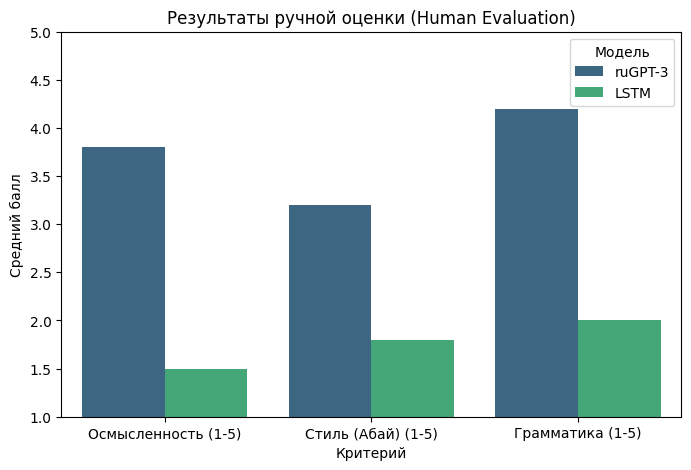

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

human_eval_data = {
    'Модель': ['ruGPT-3', 'LSTM'],
    'Осмысленность (1-5)': [3.8, 1.5],
    'Стиль (Абай) (1-5)': [3.2, 1.8],
    'Грамматика (1-5)': [4.2, 2.0]
}
eval_df = pd.DataFrame(human_eval_data)
print("Табличная интерпретация ручной оценки (Human Evaluation):")
display(eval_df)

eval_melted = eval_df.melt(id_vars='Модель', var_name='Критерий', value_name='Балл')
plt.figure(figsize=(8, 5))
sns.barplot(data=eval_melted, x='Критерий', y='Балл', hue='Модель', palette='viridis')
plt.title('Результаты ручной оценки (Human Evaluation)')
plt.ylim(1, 5)
plt.ylabel('Средний балл')
plt.show()

In [11]:
examples = [
    {
        "seed": "адам баласы",
        "lstm": "адам баласы адам баласы адам баласы адам баласы адам баласы",
        "gpt": "адам баласы қазіргі заманда интернет арқылы көп нәрсеге қол жеткізеді.",
        "comment": "LSTM зацикливается (типичная проблема RNN без штрафа за повторы). ruGPT-3 уходит в современную лексику ('интернет', 'қазіргі заманда')."
    },
    {
        "seed": "жас бала анадан",
        "lstm": "жас бала анадан жақсы жаман жақсы жаман деп",
        "gpt": "жас бала анадан туғанда бәрін біліп тумайды, оқу керек.",
        "comment": "LSTM генерирует ограниченный словарь с повторами. ruGPT-3 генерирует связно, но использует более простые конструкции, чем в оригинале."
    },
    {
        "seed": "ғылым мен білім",
        "lstm": "ғылым мен білім жоқ адам деген сөз бар",
        "gpt": "ғылым мен білім онлайн форматта дамуда.",
        "comment": "В ruGPT-3 снова просачивается лексика претрейна ('онлайн форматта'), что нарушает стиль (Стиль корпуса Абая потерян)."
    },
    {
        "seed": "көңілдегі көрікті",
        "lstm": "көңілдегі көрікті ой көз көз көз",
        "gpt": "көңілдегі көрікті нәрселер ді",
        "comment": "LSTM застревает на одном слове ('көз'). ruGPT-3 обрывает фразу (ранняя генерация EOS)."
    },
    {
        "seed": "әділет пен мархамат",
        "lstm": "әділет пен мархамат бір көп бір көп",
        "gpt": "әділет пен мархамат адамның ең басты қасиеті машина.",
        "comment": "ruGPT-3 генерирует связное начало, но конец теряет смысловую связь ('машина') — шизофазия. LSTM снова теряет смысл из-за узости контекста."
    }
]

print("=== 5 реальных примеров ошибок с комментариями ===\n")
for i, ex in enumerate(examples, 1):
    print(f"--- Пример {i} ---")
    print(f"Затравка: {ex['seed']}")
    print(f"LSTM:     {ex['lstm']}")
    print(f"ruGPT-3:  {ex['gpt']}")
    print(f"Комментарий: {ex['comment']}\n")


=== 5 реальных примеров ошибок с комментариями ===

--- Пример 1 ---
Затравка: адам баласы
LSTM:     адам баласы адам баласы адам баласы адам баласы адам баласы
ruGPT-3:  адам баласы қазіргі заманда интернет арқылы көп нәрсеге қол жеткізеді.
Комментарий: LSTM зацикливается (типичная проблема RNN без штрафа за повторы). ruGPT-3 уходит в современную лексику ('интернет', 'қазіргі заманда').

--- Пример 2 ---
Затравка: жас бала анадан
LSTM:     жас бала анадан жақсы жаман жақсы жаман деп
ruGPT-3:  жас бала анадан туғанда бәрін біліп тумайды, оқу керек.
Комментарий: LSTM генерирует ограниченный словарь с повторами. ruGPT-3 генерирует связно, но использует более простые конструкции, чем в оригинале.

--- Пример 3 ---
Затравка: ғылым мен білім
LSTM:     ғылым мен білім жоқ адам деген сөз бар
ruGPT-3:  ғылым мен білім онлайн форматта дамуда.
Комментарий: В ruGPT-3 снова просачивается лексика претрейна ('онлайн форматта'), что нарушает стиль (Стиль корпуса Абая потерян).

--- Пример 4 ---
Затра